# Modelo de Riesgo de Crédito
### Fase 2 - Motor de decisión y política de concesión

**Autor:** Adrian Sabin Pelayo · Data Science | Riesgo de Crédito
**Ámbito:** Banca minorista - admisión y scoring

---

## Resumen ejecutivo

La fase 1 dejó la cartera depurada y las señales de morosidad identificadas. Esta fase construye el motor que estima la **probabilidad de impago** de cada solicitante y la convierte en una **decisión de concesión que minimiza la pérdida del banco**.

| Paso | Contenido |
|---|---|
| 1 | **Baseline** - regresión logística como referencia |
| 2 | **Feature engineering** - indicadores de solvencia, carga de deuda y mora |
| 3 | **Selección y tuning** - comparativa de modelos y optimización |
| 4 | **Umbral por coste** - calibración en euros, no en métricas |
| 5 | **Explicabilidad** - SHAP y trazabilidad regulatoria |

> Un modelo de riesgo no se elige por su AUC, sino por **cuánto dinero ahorra** con una política de concesión defendible.

## 1. Entorno

Librerías de modelado y paleta corporativa, coherente con la fase de análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Paleta corporativa
COLOR_PRINCIPAL = "#4A90D9" 
COLOR_ALERTA    = "#E05C5C"   
COLOR_NEUTRO    = "#7F8C99"   

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 90

## 2. Carga de la cartera

Cartera depurada en fase 1. Se separa en **características del cliente** (`x`, lo conocido en el momento de la solicitud) y **variable objetivo** (`y`, si acabó impagando).

In [2]:
df = pd.read_parquet("data/datos_limpios.parquet")

x = df.drop(["SeriousDlqin2yrs"], axis=1)   # Características del cliente
y = df["SeriousDlqin2yrs"]                   # Resultado: 1 = impago grave, 0 = al corriente

## 3. Baseline: regresión logística

Modelo simple y transparente que fija el listón: cualquier modelo posterior debe superarlo para justificar su complejidad.

Partición **80/20 estratificada** - se conserva la proporción de morosos en ambos bloques, imprescindible con clases desbalanceadas. El 20% de test no se usa en el entrenamiento, de modo que mide el comportamiento ante clientes nuevos.

In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

logit_model = LogisticRegression(max_iter=3000, random_state=42)
logit_model.fit(x_train, y_train)

y_pred = logit_model.predict(x_test)
y_prob = logit_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27861
           1       0.62      0.18      0.28      2002

    accuracy                           0.94     29863
   macro avg       0.78      0.58      0.62     29863
weighted avg       0.92      0.94      0.92     29863

AUC-ROC: 0.8500


### Lectura de negocio

**AUC 0,86** - discrimina bien. Pero el **recall sobre morosos es mínimo**: detecta una fracción pequeña de los que realmente impagan.

Para el banco eso es lo que importa: cada moroso no detectado es capital perdido. Es el punto a atacar en los siguientes pasos, empezando por darle mejor información al modelo.

## 4. Feature engineering

Las variables en bruto describen al cliente; la señal fuerte aparece al **combinarlas**. Se construyen 9 indicadores con lectura financiera directa:

| Variable | Qué mide |
|---|---|
| `TotalDaysLate` | Episodios de mora acumulados (cualquier severidad) |
| `SevereMoraPct` | Peso de la mora grave sobre el total |
| `IncomePerDependent` | Renta ajustada por carga familiar |
| `MonthlyDebtPayment` | Cuota mensual comprometida |
| `DisposableIncome` | Ingreso libre tras atender deuda → solvencia efectiva |
| `RealEstateLoanRatio` | Peso hipotecario sobre el crédito total |
| `HasSevereMora` / `HasAnyMora` | Banderas binarias de alerta |
| `AgeBucket` | Tramos de edad - el riesgo por edad no es lineal |

In [4]:
# Total episodios de mora (cualquier severidad)
df["TotalDaysLate"] = (df["NumberOfTime30-59DaysPastDueNotWorse"] +
                        df["NumberOfTime60-89DaysPastDueNotWorse"] +
                        df["NumberOfTimes90DaysLate"])

# Proporción de mora grave sobre total de mora
df["SevereMoraPct"] = df["NumberOfTimes90DaysLate"] / (df["TotalDaysLate"] + 1)

# Ingreso por dependiente (carga familiar)
df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

# Deuda mensual estimada (DebtRatio * MonthlyIncome)
df["MonthlyDebtPayment"] = df["DebtRatio"] * df["MonthlyIncome"]

# Ingreso disponible tras deuda
df["DisposableIncome"] = df["MonthlyIncome"] - df["MonthlyDebtPayment"]

# Ratio préstamos inmobiliarios sobre total líneas abiertas
df["RealEstateLoanRatio"] = df["NumberRealEstateLoansOrLines"] / (df["NumberOfOpenCreditLinesAndLoans"] + 1)

# Cliente con mora grave (binaria)
df["HasSevereMora"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)

# Cliente con cualquier mora (binaria)
df["HasAnyMora"] = (df["TotalDaysLate"] > 0).astype(int)

# Segmento de edad
df["AgeBucket"] = pd.cut(df["age"],
                          bins=[0, 30, 40, 50, 60, 70, 90],
                          labels=[1, 2, 3, 4, 5, 6]).astype(int)

x = df.drop(["SeriousDlqin2yrs"], axis=1)
y = df["SeriousDlqin2yrs"]

## 5. Selección de modelo

Se comparan tres familias con la información enriquecida. Todas con `class_weight="balanced"` para corregir el desbalanceo y forzar atención sobre el cliente moroso.

#### 5.1 Modelo basado en árboles de decisión (Random Forest)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

rf_modelo = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_modelo.fit(x_train, y_train)

y_pred = rf_modelo.predict(x_test)
y_prob = rf_modelo.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27861
           1       0.53      0.16      0.25      2002

    accuracy                           0.93     29863
   macro avg       0.74      0.58      0.61     29863
weighted avg       0.92      0.93      0.92     29863

AUC-ROC: 0.8269


#### 5.2 Modelo de alto rendimiento (LightGBM)

In [6]:
from lightgbm import LGBMClassifier

lgbm_modelo = LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)
lgbm_modelo.fit(x_train, y_train)

y_pred = lgbm_modelo.predict(x_test)
y_prob = lgbm_modelo.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27861
           1       0.22      0.74      0.34      2002

    accuracy                           0.81     29863
   macro avg       0.60      0.78      0.62     29863
weighted avg       0.93      0.81      0.85     29863

AUC-ROC: 0.8573


### Comparativa

| Modelo | AUC | Recall (umbral 0,5) |
|---|---|---|
| Regresión logística | 0,850 | 0,18 |
| Random Forest | 0,827 | 0,16 |
| **LightGBM** | **0,857** | 0,74 |

**El hallazgo:** los tres discriminan igual, pero **deciden** de forma radicalmente distinta. LightGBM captura a la gran mayoría de los morosos -lo que el banco necesita- a costa de más falsas alarmas.

Esa tensión entre cobertura y falsas alarmas es una decisión de negocio, no técnica, y se resuelve en la sección 7 poniéndole precio a cada error. **Se selecciona LightGBM** por su flexibilidad para ajustarse a ese punto de operación.

## 6. Optimización de hiperparámetros

`RandomizedSearchCV` con 30 combinaciones y validación cruzada a 5 folds sobre el espacio de profundidad, learning rate, regularización y `scale_pos_weight`. Métrica de selección: AUC.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
import logging

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "min_child_samples": [50, 100, 200],
    "verbose": [-1]
}

lgbm_base = LGBMClassifier(random_state=42, verbose=-1)

search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

logging.getLogger("lightgbm").setLevel(logging.ERROR)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search.fit(x_train, y_train)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor capacidad de discriminación (validación): {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'verbose': -1, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 100, 'max_depth': 3, 'learning_rate': 0.05}
Mejor capacidad de discriminación (validación): 0.8670


In [8]:
best_params = search.best_params_

lgbm_tuned = LGBMClassifier(random_state=42, **best_params)
lgbm_tuned.fit(x_train, y_train)

y_pred = lgbm_tuned.predict(x_test)
y_prob = lgbm_tuned.predict_proba(x_test)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

AUC-ROC: 0.8589


### Conclusión del tuning

La AUC se estabiliza en **0,859**: el límite ya no está en el modelo, sino en la información disponible. Es el techo habitual en riesgo de crédito con datos de una sola entidad; el salto siguiente vendría de incorporar bureau externo (CIRBE).

El rendimiento operativo del modelo no se mide aquí, sino en la sección 7, una vez fijado el umbral de concesión.

## 7. Del riesgo al euro: el umbral de concesión

El modelo entrega una probabilidad; la dirección necesita una **decisión**. Esa frontera no se fija por convención (0,5) sino según **cuánto cuesta cada error**:

| Error | Qué pasa | Coste |
|---|---|---|
| **Falso negativo** - se concede a un futuro moroso | El banco no recupera el capital | **20.000 €** |
| **Falso positivo** - se rechaza a un buen cliente | Margen no ganado | **1.000 €** |

**Equivocarse concediendo cuesta 20 veces más que equivocarse rechazando.** De ahí que al banco le compense filtrar con dureza.

Se barre el umbral de 0,01 a 0,99 y se retiene el que minimiza `FN·20.000 + FP·1.000`.

> Importes orientativos para banca minorista. El área financiera introduce sus cifras reales y la política se recalcula sola.

Punto de corte óptimo: 0.05
Coste total mínimo para el banco: 14,606,000 €


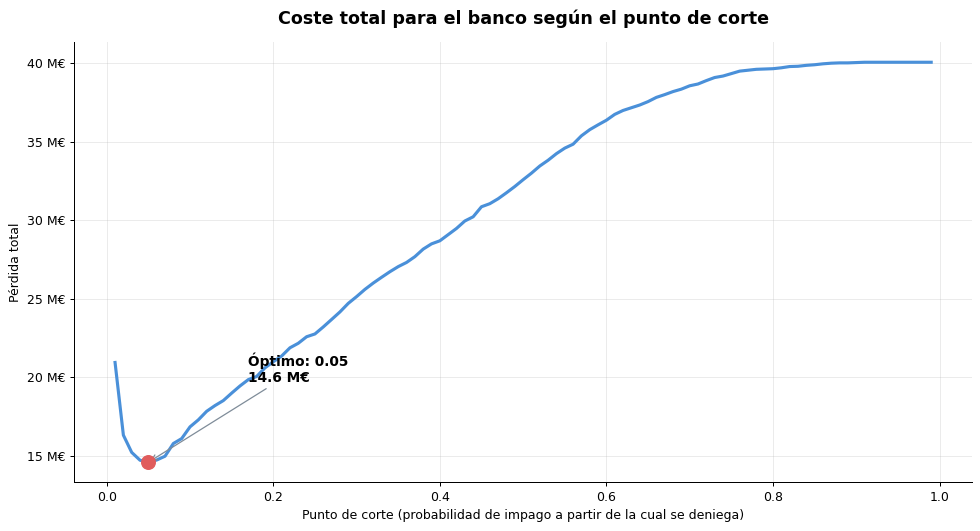

              precision    recall  f1-score   support

           0       0.98      0.73      0.84     27861
           1       0.18      0.82      0.30      2002

    accuracy                           0.74     29863
   macro avg       0.58      0.78      0.57     29863
weighted avg       0.93      0.74      0.80     29863



In [ ]:
# --- Supuestos económicos (editables con las cifras reales de la entidad) ---
coste_fn = 20000   # Pérdida por impago NO detectado (falso negativo)
coste_fp = 1000    # Coste de oportunidad por rechazar a un buen cliente (falso positivo)

# Evaluar el coste total del banco para cada posible punto de corte
thresholds = np.arange(0.01, 1.0, 0.01)
costes = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()   # morosos que se cuelan
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()   # buenos clientes rechazados
    costes.append((fn * coste_fn) + (fp * coste_fp))

# Punto de corte que minimiza la pérdida total
threshold_optimo = thresholds[np.argmin(costes)]
print(f"Punto de corte óptimo: {threshold_optimo:.2f}")
print(f"Coste total mínimo para el banco: {min(costes):,.0f} €")

# Visualización de la curva de coste
plt.figure(figsize=(11, 6))
plt.plot(thresholds, costes, color=COLOR_PRINCIPAL, lw=2.5)

# Marcar el mínimo
plt.scatter(threshold_optimo, min(costes), color=COLOR_ALERTA, s=120, zorder=5)
plt.annotate(f"Óptimo: {threshold_optimo:.2f}\n{min(costes)/1e6:.1f} M€",
             xy=(threshold_optimo, min(costes)),
             xytext=(threshold_optimo + 0.12, min(costes) * 1.35),
             arrowprops=dict(arrowstyle="->", color=COLOR_NEUTRO),
             fontsize=11, fontweight="bold")

# Eje Y en millones, no en notación científica
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x/1e6:.0f} M€"))

plt.title("Coste total para el banco según el punto de corte", fontsize=14, pad=15)
plt.xlabel("Punto de corte (probabilidad de impago a partir de la cual se deniega)")
plt.ylabel("Pérdida total")
plt.grid(alpha=0.25)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Rendimiento del modelo aplicando el punto de corte óptimo
y_pred_optimo = (y_prob >= threshold_optimo).astype(int)
print(classification_report(y_test, y_pred_optimo))

### Lectura de negocio

La curva tiene un mínimo claro, y **no está en el umbral por defecto**: la política óptima es **más estricta**.

La razón es puramente económica: con un ratio de coste 20:1, compensa rechazar algún cliente solvente de más si con ello se evitan impagos.

Este es el entregable para la dirección: no una métrica, sino **una regla de concesión concreta, justificada en euros y que se recalibra sola** cuando cambien los costes reales.

## 8. Explicabilidad (SHAP)

En banca no basta con acertar: el regulador y el comité de riesgos exigen **entender el porqué**. Valores SHAP sobre el conjunto de test para cuantificar el peso de cada variable en las decisiones.

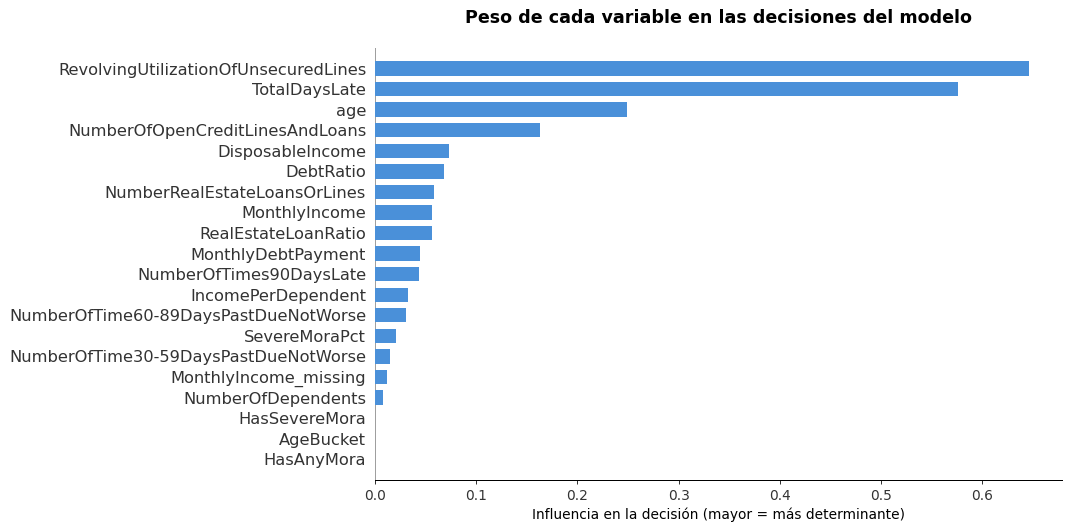

In [10]:
import shap

explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(
    shap_values,
    x_test,
    plot_type="bar",
    plot_size=(12, 6),
    color=COLOR_PRINCIPAL,
    show=False
)
plt.title("Peso de cada variable en las decisiones del modelo", fontsize=14, pad=20)
plt.xlabel("Influencia en la decisión (mayor = más determinante)", fontsize=11)
plt.tight_layout()
plt.show()

### Lectura de negocio

**Dos palancas dominantes:** uso del crédito rotativo e historial de mora acumulado. Ambas son señales directas de tensión financiera -cliente que apura su línea y arrastra retrasos-, y cualquier analista de riesgo las reconocería como sensatas.

**Segunda capa:** edad y número de líneas abiertas (exposición total). Confirma el perfil detectado en fase 1: joven y con amplia exposición crediticia.

**Las variables construidas aportan:** destaca `DisposableIncome`, que el modelo usa como medida de solvencia efectiva. Otras banderas binarias resultaron redundantes - información útil para depurar la próxima versión.

> **Cumplimiento.** El modelo decide sobre variables financieramente coherentes, sin señales discriminatorias. Cumple los marcos de gobernanza de modelos en banca (SR 11-7, directrices EBA) y facilita la validación interna.

## 9. Conclusiones y recomendaciones

### Qué se ha construido

1. **Un scoring** con AUC 0,86 que estima la probabilidad de impago de cada solicitante.
2. **Una regla de concesión calibrada en euros**, que fija el umbral donde la pérdida esperada del banco es mínima.
3. **Un modelo auditable**, que decide sobre variables financieras interpretables y cumple los requisitos de gobernanza.

### Recomendaciones

| Recomendación | Por qué |
|---|---|
| Aplicar el umbral óptimo en la concesión | Es el que minimiza la pérdida esperada |
| Validar los costes con el área financiera | La regla depende de las cifras reales de pérdida y margen |
| Priorizar crédito rotativo e historial de mora | Son las dos señales que mejor anticipan el impago |
| Incorporar bureau de crédito (CIRBE) | Vía más directa para romper el techo de 0,86 |
| Pasar validación de riesgos antes de producción | Paso obligado; el modelo lo permite por su transparencia |

### Cierre

El modelo estima quién va a impagar y convierte esa estimación en una decisión de conceder o rechazar que minimiza la pérdida. Requiere validación del área de riesgos antes de producción.

In [11]:
import joblib, json

joblib.dump(lgbm_tuned, "data/modelo_lgbm.pkl")
np.save("data/y_prob.npy", y_prob)
np.save("data/y_test.npy", y_test.values)

politica = {
    "threshold_optimo": float(threshold_optimo),
    "coste_fn": coste_fn,
    "coste_fp": coste_fp,
}
json.dump(politica, open("data/politica.json", "w"), indent=2)
print("Modelo y predicciones guardados")

Modelo y predicciones guardados
